In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
# Standard library imports
import sys
import os
import glob
from pathlib import Path

# Scientific and I/O libraries
import numpy as np
from scipy.io import loadmat
from scipy.stats import zscore
import pickle
import mat73
import h5py
# Add custom utilities to path
sys.path.append('/home/asantoro/research/')

# Custom and plotting imports
from utils_neuromaps_brain import normal_view 
from matplotlib import rcParams

import matplotlib.pyplot as plt

# Set matplotlib font preferences
rcParams["font.family"] = ["DejaVu Serif"]


/media/RCPNAS/Data/NeuroTin_HOI/conda_env/tinnitus/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Loading the data

In [60]:
data_out = '../../Cleaned/rsfMRI'
data_all = {}
pickle_files = glob.glob(os.path.join(data_out, '*_TC_Schaefer.pkl'))

for pf in pickle_files:
    subjID = os.path.basename(pf).split('_TC_Schaefer.pkl')[0]
    with open(pf, 'rb') as f:
        data_all[subjID] = pickle.load(f)

pickle_file = os.path.join(data_out, 'rsfMRI_utils.pkl')
with open(pickle_file, 'rb') as f:
    rsfMRI_utils=pickle.load(f)


In [91]:
Nparcels=200
## Indices for the Auditory Cortex in schaefer 
ACidx = np.concatenate([rsfMRI_utils['AudROI']['L'][Nparcels], rsfMRI_utils['AudROI']['R'][Nparcels]], dtype=int)

In [92]:

# Compute correlation matrices for each subject and session (V01_{Nparcels} to V15_{Nparcels}),
# excluding the time points specified in rsfMRI_utils['FDindices']

subject_corr_matrices = {}

for subj in data_all:
    subject_corr_matrices[subj] = {}
    # Find all session keys for this subject that match 'V' and end with '_{Nparcels}'
    session_keys = [k for k in data_all[subj].keys() if k.startswith('V') and k.endswith(f'_{Nparcels}')]
    for sess in session_keys:
        ts = data_all[subj][sess]  # Get the time series data for this subject/session
        sess_short = sess[:3]  # Determine the session short name (e.g., 'V01' from 'V01_{Nparcels}')
        try:
            fd_indices = rsfMRI_utils['FDindices'][subj][sess_short]  # Get indices to exclude due to FD
        except KeyError:
            fd_indices = None  # If not found, set to None
            print("Indices not found:", subj, sess)
        # Handle cases for fd_indices: nan, float, array, or None
        if isinstance(fd_indices, float):  # If nan, treat as no indices to exclude
            timepoints_to_keep = np.arange(ts.shape[0])
        elif fd_indices is None:  # If not found, use all time points
            timepoints_to_keep = np.arange(ts.shape[0])
        elif isinstance(fd_indices, np.ndarray):
            if fd_indices.size == 0:  # If empty array, use all time points
                timepoints_to_keep = np.arange(ts.shape[0])
            else:
                timepoints_to_keep = np.setdiff1d(np.arange(ts.shape[0]), fd_indices.astype(int))  # Exclude FD indices
        else:
            timepoints_to_keep = np.arange(ts.shape[0])  # Fallback: use all time points
        ts_selected = ts[timepoints_to_keep, :]  # Select only the time points to keep
        corr_mat = np.corrcoef(ts_selected.T)  # Compute the correlation matrix (regions x regions)
        subject_corr_matrices[subj][sess] = corr_mat  # Store the result


In [ ]:
# Create a new nested dictionary to store the masked correlation matrices
subject_corr_matrices_masked = {}

for subj in subject_corr_matrices:
    subject_corr_matrices_masked[subj] = {}
    for sess in subject_corr_matrices[subj]:
        # Copy the correlation matrix to avoid modifying the original
        corr_mat = subject_corr_matrices[subj][sess].copy()
        # Get the indices to mask (set to nan)
        pc_indices = np.array(rsfMRI_utils['PCidx'][subj][Nparcels],dtype=int)-1
        # Set the specified rows and columns to nan
        corr_mat[pc_indices, :] = np.nan
        corr_mat[:, pc_indices] = np.nan
        # Store the masked matrix
        subject_corr_matrices_masked[subj][sess] = corr_mat

In [134]:
data_all['002GNV']['V01_200'].shape

(320, 219)

In [140]:
dataHCP =loadmat('/media/miplab-nas2/HCP-Data/HCP_100unrelated_preprocessed_ERG/data/100307/rfMRI_REST1_LR/Schaefer200/TS_Schaefer200S.mat')['TS']

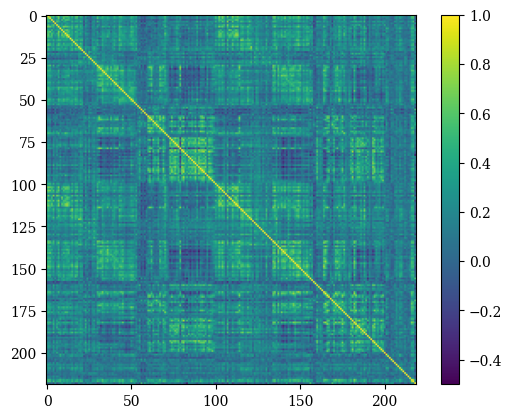

In [145]:
plt.imshow(np.corrcoef(dataHCP[:,:320]),vmin=-0.5,vmax=1)
plt.colorbar()

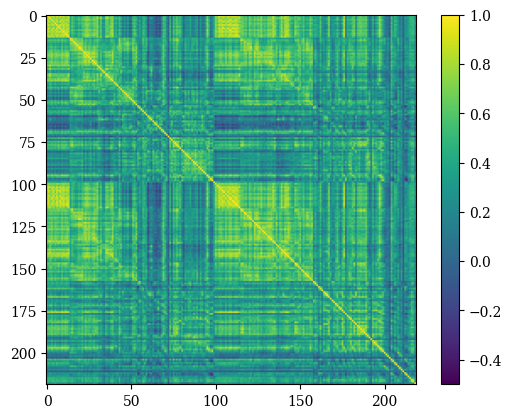

In [139]:
plt.imshow(subject_corr_matrices['026GNV']['V01_200'],vmin=-0.5,vmax=1)
plt.colorbar()

In [160]:
# Check the length for all the arrays in the nested dictionary and sort subjects by their average length
fd_indices = rsfMRI_utils['FDindices']

subject_avg_lengths = {}
for subj, sess_dict in fd_indices.items():
    lengths = []
    for arr in sess_dict.values():
        # Only count length if arr is array-like (has __len__)
        if hasattr(arr, '__len__') and not isinstance(arr, (str, bytes)):
            lengths.append(len(arr))
        else:
            # If arr is not array-like, skip or treat as length 0
            continue
    avg_length = np.mean(lengths) if lengths else 0
    subject_avg_lengths[subj] = avg_length

# Sort subjects by their average length (descending order)
sorted_subjects = sorted(subject_avg_lengths.items(), key=lambda x: x[1], reverse=True)

# Print sorted subjects and their average lengths
for subj, avg_len in sorted_subjects:
    print(f"{subj}: average length = {avg_len:.2f}")

008GNV: average length = 73.00
002GNV: average length = 51.79
048GNV: average length = 47.80
012GNV: average length = 41.20
043GNV: average length = 30.20
025GNV: average length = 26.73
034GNV: average length = 18.27
021GNV: average length = 14.80
003GNV: average length = 11.29
026GNV: average length = 11.13
037GNV: average length = 7.27
054GNV: average length = 7.27
020GNV: average length = 7.07
016GNV: average length = 6.87
004GNV: average length = 6.00
049GNV: average length = 5.60
023GNV: average length = 3.67
013GNV: average length = 1.60
005GNV: average length = 1.07
056GNV: average length = 0.93
041GNV: average length = 0.80


### Example: Compute and plot the correlation matrix heatmap for subject '008GNV', session 'V01_400'

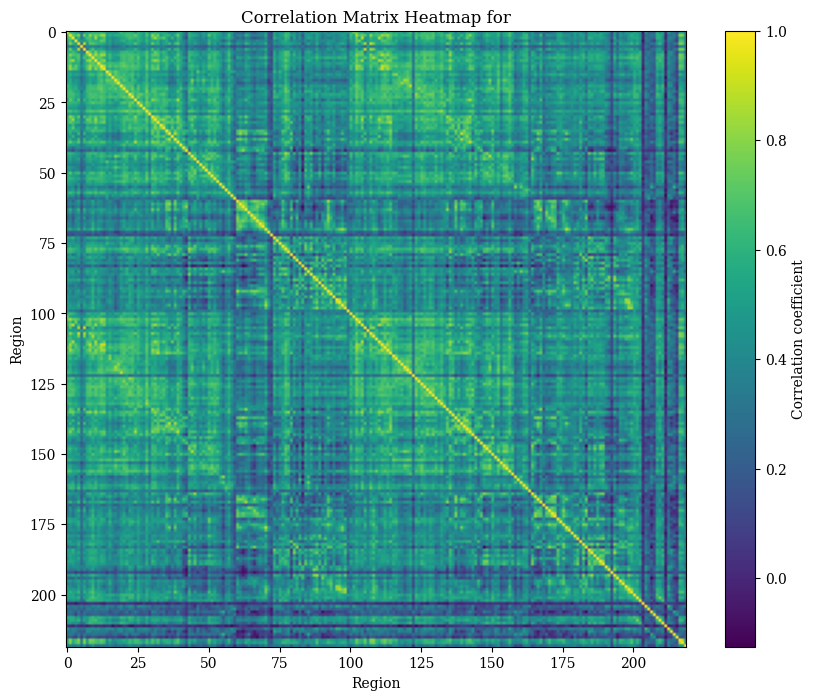

In [172]:
# Compute the correlation matrix for the time series data of subject '008GNV', session 'V01_400'
corr_matrix = np.corrcoef(data_all['023GNV']['V10_200'].T)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Correlation coefficient')
plt.title("Correlation Matrix Heatmap for")
plt.xlabel("Region")
plt.ylabel("Region")
plt.show()

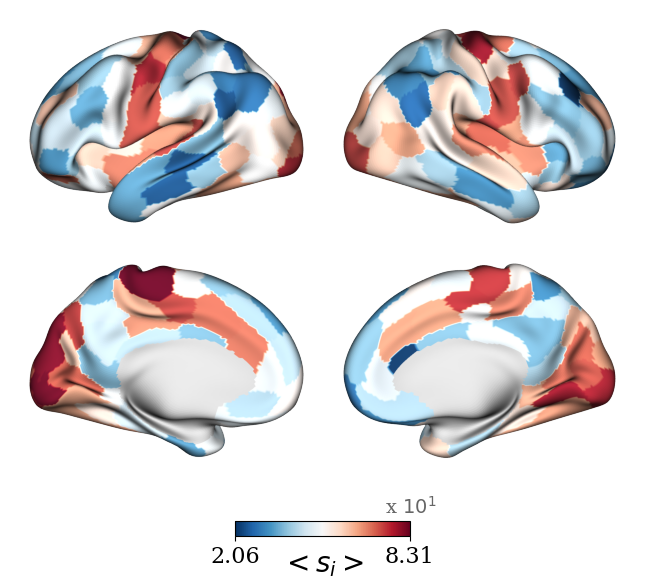

In [15]:
### Plotting the nodal strength (you need to stop at 200-> only cortical regions)
normal_view(np.sum(corr_matrix,axis=1)[:200],parcellation=200);

### Compute the subject-session pair comparison to create the Identifiability matrix

In [11]:
# Step 1: Get sorted list of subject IDs
subject_ids = sorted(data_all.keys())
parc_sel='200'
# Step 2: Collect all unique session names containing the given parcellation across all subjects, then sort them
session_names = sorted({k for subj in subject_ids for k in data_all[subj].keys() if parc_sel in k})

# Step 3: Prepare containers for upper triangle vectors, labels, and session counts per subject
upper_tri_vectors = []  # Will hold the upper triangle of each correlation matrix
labels = []             # Will hold subject_session labels for each vector
count_subjs_session = {subj: 0 for subj in subject_ids}  # Track number of sessions per subject

# Step 4: For each subject and each session, extract the upper triangle of the correlation matrix
for subj in subject_ids:
    for sess in session_names:
        if sess in data_all[subj]:
            # Increment session count for this subject
            count_subjs_session[subj] += 1
            # Compute correlation matrix for the session's time series (regions x timepoints)
            corr_matrix = np.nan_to_num(np.corrcoef(data_all[subj][sess].T))
            # Extract the upper triangle (excluding the diagonal) as a 1D vector
            upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
            upper_tri_vectors.append(upper_tri)
            # Store the label for this subject-session pair
            labels.append(f"{subj}_{sess}")

# Step 5: Convert list of upper triangle vectors to a numpy array (n_pairs x n_features)
upper_tri_vectors = np.array(upper_tri_vectors)

# Step 6: Compute the correlation matrix between all subject-session pairs (the fingerprinting matrix)
big_corr_matrix = np.corrcoef(upper_tri_vectors)


/home/asantoro/anaconda3/envs/tinnitus/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/asantoro/anaconda3/envs/tinnitus/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
### Notice: not all the subjects have the same number of resting-state sessions
count_subjs_session

{'002GNV': 14,
 '003GNV': 14,
 '004GNV': 15,
 '005GNV': 15,
 '008GNV': 15,
 '012GNV': 15,
 '013GNV': 15,
 '016GNV': 15,
 '020GNV': 15,
 '021GNV': 15,
 '023GNV': 15,
 '025GNV': 15,
 '026GNV': 15,
 '034GNV': 15,
 '037GNV': 15,
 '041GNV': 15,
 '043GNV': 15,
 '048GNV': 15,
 '049GNV': 15,
 '054GNV': 15,
 '056GNV': 15}

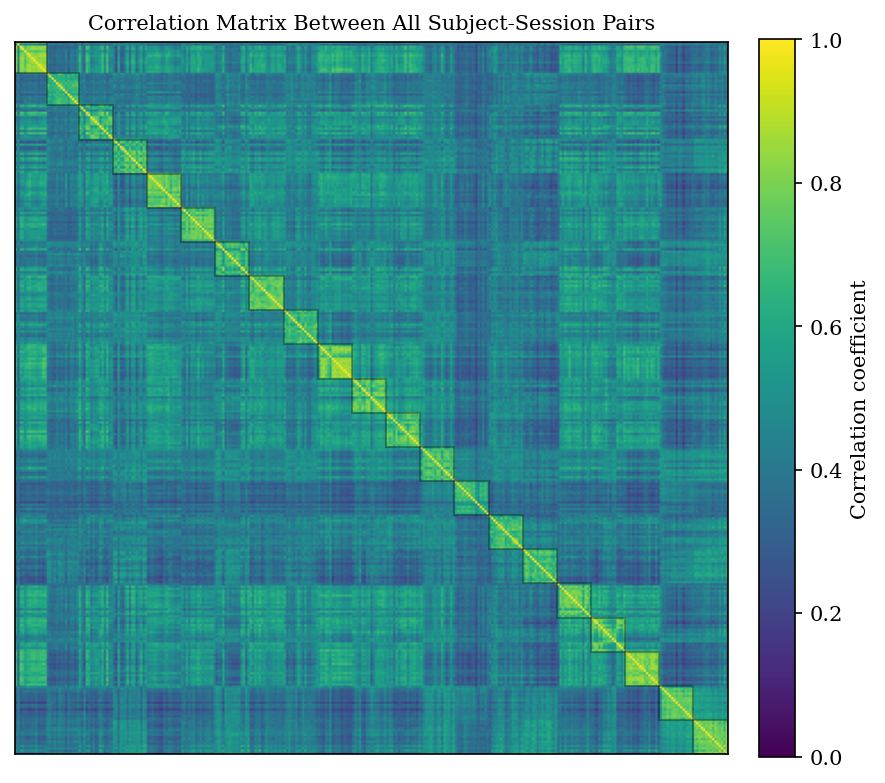

In [14]:
plt.figure(figsize=(6,6),dpi=150)
im = plt.imshow(big_corr_matrix, cmap='viridis', vmin=0, vmax=1)  # Set aspect to 'square'
plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation coefficient')
plt.title("Correlation Matrix Between All Subject-Session Pairs",fontsize=10)
plt.xticks([])
plt.yticks([])

# Draw boxes along the diagonal to highlight each subject's block
block_sizes = []
for subj in sorted(data_all.keys()):
    count = sum([1 for sess in session_names if sess in data_all[subj]])
    block_sizes.append(count)

start = 0
for size in block_sizes:
    end = start + size
    rect = plt.Rectangle((start-0.5, start-0.5), size, size, fill=False, edgecolor='k', linewidth=1,alpha=0.3)
    plt.gca().add_patch(rect)
    start = end

plt.tight_layout()
plt.show()